In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


In [2]:
#Load data set
data = np.load("/home/amirali/Desktop/Amirali/CESARP/cesarp/cesarp_examples/random_idf_generator/final_tensor_test.npy")
data[:,:,1,1].shape

(365, 24)

In [4]:
#Calculate annual heating load
Annual_HL = []

for i in range(0,125):
    Alt_HL = data[:,:,0,i]
    Ave_HL = np.sum(Alt_HL)
    Annual_HL.append(Ave_HL)

print(Annual_HL)

[38987.55960484267, 45190.5344077743, 44084.42880178415, 40547.940208636915, 74523.7723656659, 50837.74836545879, 22231.837956415555, 123303.2246611162, 71024.70381890476, 39828.96167559462, 42264.635092222146, 36761.880871545334, 31119.209450598366, 21995.773952309428, 61594.76525936028, 51819.7486507372, 25562.572410841258, 62597.259012616414, 77502.28794580633, 20688.328801362877, 49842.75498781205, 35657.841102578335, 82387.26182024878, 49260.750167688566, 22149.343364610453, 33264.44217758309, 39899.70396520471, 26629.66614828803, 30906.753014348706, 76666.7712202604, 72166.95472058142, 57018.68846929295, 63485.46079870331, 39174.78814745035, 54384.11059669458, 82485.85455517775, 61935.00390104858, 44689.09564198023, 45856.424317596706, 13921.219769856236, 111677.01082909538, 96733.00628261767, 93739.04719180589, 39343.428983179, 22552.767464903583, 77786.52325847089, 50605.352381581106, 31465.653774051985, 46986.955191230445, 90419.40080707174, 35271.167477507435, 57545.126940345

In [6]:
#Calculate annual plug load
Annual_PL = []

for i in range(0,125):
    Alt_PL = data[:,:,1,i]
    Ave_PL = np.sum(Alt_PL)
    Annual_PL.append(Ave_PL)

print(Annual_PL)

[5870.454927715285, 7655.975187684295, 6405.49788562244, 6249.621538563011, 15556.678234106656, 6704.759032445866, 2733.455455064487, 23529.17674714151, 12658.566104463516, 7434.34264981506, 7165.790293167256, 6099.176159491898, 3330.9753535913583, 2176.545808505084, 11356.976242747363, 6250.7069621693845, 4254.963239967753, 10861.323788286945, 15514.895667404728, 2988.938645557957, 8199.792571401671, 5585.157118742808, 16413.16987199621, 8181.698410835819, 2298.448522290159, 6399.029180761536, 7900.251549548834, 3313.492448068807, 4269.058962224609, 14666.615909466964, 12591.276153299754, 10327.51607498022, 13564.305099749563, 6265.686805239588, 9552.756975279297, 17467.053180190327, 9101.504761266819, 8653.801361115682, 6670.834143853566, 1364.8054400038784, 20559.005180390865, 16440.568513094262, 18014.62536496874, 4905.756546332233, 2898.8075924794425, 14974.918047489486, 8470.181764509729, 5303.722605996338, 7125.270960057762, 16091.822461110985, 4465.2914691883625, 12309.90159964

In [28]:
#calculate Area

APPLIANCES_WATT_PER_ZONE_AREA = 6.4
LIGHTING_WATT_PER_ZONE_AREA =  10.3104
PL = APPLIANCES_WATT_PER_ZONE_AREA + LIGHTING_WATT_PER_ZONE_AREA

area = [x / PL for x in Annual_PL]

print(area)


[351.30547010935015, 458.15630910596366, 383.32403088031646, 373.99592700132916, 930.9578606201321, 401.2327073227371, 163.57809837373654, 1408.0558662354888, 757.5262174731614, 444.8931593387986, 428.8221881682818, 364.99282838782426, 199.33546495543843, 130.25096996511658, 679.6352117691596, 374.0608819758584, 254.62964620641952, 649.9738957946515, 928.4574676491723, 178.8669717994756, 490.69995759537, 334.232401303548, 982.2128657600184, 489.6171492505158, 137.54599065792314, 382.9369243561815, 472.77453259938926, 198.2892359290506, 255.4731761193394, 877.6938858116481, 753.4993868070037, 618.029255731773, 811.7283308448369, 374.9573203058926, 571.6653685895787, 1045.2803751071385, 544.6610949628266, 517.8691929047588, 399.2025411632017, 81.67401378805286, 1230.311972208377, 983.8524818732204, 1078.0487220514613, 293.57505184389555, 173.4732617100394, 896.1436020376224, 506.88085051882234, 317.3905236257862, 426.39739084987565, 962.9824816348493, 267.21631254717795, 736.661097259613

In [37]:
#Normalize Heating load 

Annual_HL_Normalized = [num / denom for num, denom in zip(Annual_HL, area)]

print(Annual_HL_Normalized)


[110.97908493342585, 98.63562611624432, 115.00564861676631, 108.41813314317942, 80.05063979590219, 126.70389885380591, 135.90962468350233, 87.56983839765806, 93.7587402001979, 89.52477879135864, 98.55981397034503, 100.71946080125137, 156.11476591762076, 168.87224684929618, 90.62915545388363, 138.5329264504103, 100.39118693240675, 96.30734313735114, 83.47424695935712, 115.66321380202139, 101.57481005717197, 106.68577003159572, 83.87923299752241, 100.61075320399773, 161.03227188712367, 86.86663536954406, 84.3947827431182, 134.2970838710394, 120.97846624770973, 87.35023959904055, 95.77573118724486, 92.2588824727729, 78.21023165795928, 104.47799262991134, 95.13277099655672, 78.91265972225219, 113.71292070213987, 86.29417670380518, 114.87007117735183, 170.4485811849816, 90.77129488436834, 98.32064060908952, 86.95251455187125, 134.0148923965764, 130.0071679207862, 86.80140446419793, 99.83678083278063, 99.13860506796674, 110.19522210860205, 93.89516687112241, 131.9948140189989, 78.11614751262

In [7]:
#Calculate T0
Average_T0 = []

for i in range(0,125):
    Alt_T0 = data[:,:,2,i]
    Ave_T0 = np.mean(Alt_T0)
    Average_T0.append(Ave_T0)

print(Average_T0)

[20.23444285646393, 20.298436951073274, 20.14513081676522, 20.206415648458123, 20.223989938098722, 20.26770348590294, 20.32547768175534, 20.358094309208315, 20.213784109972906, 20.110730861688264, 20.31423627500934, 20.322365199905075, 20.258548429898873, 20.134587356976184, 20.380989939003584, 20.15915302494912, 20.258259540527725, 20.234976555496605, 20.244630570988765, 20.007688052217933, 20.297226012379287, 20.05708956671202, 20.181422549667992, 20.148403808218703, 20.16263017798979, 20.133050260900745, 20.169440064081616, 20.167939171022358, 20.228493642035875, 20.192633717268475, 20.31740073005499, 20.306272118592265, 20.08524000400736, 20.164674035341378, 20.30195632261002, 20.168869365178107, 20.09775796798263, 20.171820588825923, 20.3385273778946, 20.3270973659511, 20.189151176048796, 20.369627848781406, 20.211581788335636, 20.08899555367569, 20.18953507919206, 20.25507826501012, 20.29950160534786, 20.174251102951878, 20.22474213232473, 19.983390557563325, 20.15177503059732, 2

In [9]:
#Floor Number calculation

floor_num = []

for i in range(0,125):
    flo = 1
    for j in range(2,9):
        if data[1,1,j,i] != -999.0:
            continue
        else:
            flo = flo+1 
    floor_num.append(flo)
    
print(floor_num)


[2, 5, 6, 5, 1, 5, 7, 1, 2, 5, 4, 4, 7, 7, 4, 6, 6, 2, 3, 7, 5, 6, 1, 5, 6, 6, 5, 7, 5, 3, 1, 4, 4, 6, 5, 3, 2, 5, 1, 7, 1, 3, 2, 4, 6, 3, 2, 5, 5, 3, 3, 4, 2, 1, 6, 4, 2, 3, 3, 1, 3, 5, 3, 7, 5, 1, 6, 1, 5, 1, 6, 2, 5, 2, 3, 4, 5, 4, 4, 6, 7, 2, 4, 3, 3, 5, 5, 4, 5, 5, 3, 2, 6, 4, 4, 2, 4, 1, 6, 1, 2, 7, 5, 4, 4, 2, 1, 2, 2, 3, 3, 1, 4, 1, 1, 6, 4, 3, 4, 4, 6, 4, 6, 4, 3]


In [14]:
#Categorize in a dictionary
dic_flo_num = defaultdict(list)

for index, floors in enumerate(floor_num):
    dic_flo_num[floors].append(index)

dic_flo_num = dict(dic_flo_num)

print(dic_flo_num)


{2: [0, 8, 17, 36, 42, 46, 52, 56, 71, 73, 81, 91, 95, 100, 105, 107, 108], 5: [1, 3, 5, 9, 20, 23, 26, 28, 34, 37, 47, 48, 61, 64, 68, 72, 76, 85, 86, 88, 89, 102], 6: [2, 15, 16, 21, 24, 25, 33, 44, 54, 66, 70, 79, 92, 98, 115, 120, 122], 1: [4, 7, 22, 30, 38, 40, 53, 59, 65, 67, 69, 97, 99, 106, 111, 113, 114], 7: [6, 12, 13, 19, 27, 39, 63, 80, 101], 4: [10, 11, 14, 31, 32, 43, 51, 55, 75, 77, 78, 82, 87, 93, 94, 96, 103, 104, 112, 116, 118, 119, 121, 123], 3: [18, 29, 35, 41, 45, 49, 50, 57, 58, 60, 62, 74, 83, 84, 90, 109, 110, 117, 124]}


In [38]:
# Dictionary to hold AHL
AHL_dict = {}

for i in range(1, 8):
    AHLlist = [Annual_HL_Normalized[j] for j in dic_flo_num[i]]
    AHL_dict[i] = AHLlist  # Save the sublist with a unique key


print(AHL_dict)

{1: [80.05063979590219, 87.56983839765806, 83.87923299752241, 95.77573118724486, 114.87007117735183, 90.77129488436834, 79.67405249619904, 87.29879560392514, 80.74113693981624, 98.32685881420898, 96.55181101194606, 87.30264791182358, 88.30909317819022, 99.50393150892504, 90.05104174970573, 69.17310901933415, 92.85207258236511], 2: [110.97908493342585, 93.7587402001979, 96.30734313735114, 113.71292070213987, 86.95251455187125, 99.83678083278063, 87.49658788280837, 83.87600449580214, 105.34724471016057, 83.55943333166665, 117.10825103576371, 91.87495813076136, 100.43999472585331, 89.36141182535108, 74.73178488431023, 90.72472230971266, 95.4345263180559], 3: [83.47424695935712, 87.35023959904055, 78.91265972225219, 98.32064060908952, 86.80140446419793, 93.89516687112241, 131.9948140189989, 95.6295395892223, 84.7074512466406, 96.56984247307993, 90.410482317257, 99.74195308799226, 119.80574573921527, 94.03639703186464, 106.64984630179535, 97.55266027994286, 97.0620772222089, 104.90093081532

In [40]:
AHL_dict[1]

[80.05063979590219,
 87.56983839765806,
 83.87923299752241,
 95.77573118724486,
 114.87007117735183,
 90.77129488436834,
 79.67405249619904,
 87.29879560392514,
 80.74113693981624,
 98.32685881420898,
 96.55181101194606,
 87.30264791182358,
 88.30909317819022,
 99.50393150892504,
 90.05104174970573,
 69.17310901933415,
 92.85207258236511]

In [42]:
max_HL = max(AHL_dict[1])
min_HL = min(AHL_dict[1])
print(max_HL)
print(min_HL)

# Find the index of the maximum number
max_HL_index = AHL_dict[1].index(max_HL)
min_HL_index = AHL_dict[1].index(min_HL)
print(max_HL_index)
print(min_HL_index)

114.87007117735183
69.17310901933415
4
15


In [68]:
max_HL_data = data[:,:,0,7]
min_HL_data = data[:,:,0,39]

print(max_HL_data)

[[20.77444928 20.73493756 21.17424129 ... 19.40557678 20.12602682
  20.93940519]
 [22.05654499 23.54274279 25.15684391 ... 26.59313646 27.37230928
  28.14794499]
 [28.64634988 28.98076208 29.3217405  ... 30.59984628 30.88366422
  31.20569185]
 ...
 [44.14071951 44.09733872 44.27167495 ... 35.71046509 35.59802052
  35.39898026]
 [35.39637059 35.42747536 35.40054676 ... 31.59837852 31.78076629
  31.99228724]
 [32.49740526 33.35589391 34.42033934 ... 35.77481181 36.26883699
  36.77599074]]


In [43]:
data[1,1,2,0]

18.879999999999995

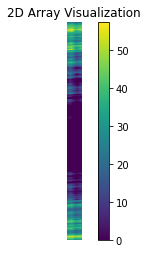

In [24]:
# Display the 2D array as an image
plt.imshow(max_HL_data, cmap='viridis')  # You can choose other colormaps like 'gray', 'hot', etc.
plt.colorbar()  # Optional: to show a color scale
plt.title('2D Array Visualization')
plt.axis('off')  # Optional: to hide the axes
plt.show()